# A Curva de Erro e a Descida do Gradiente (Cenário 2D)

Neste caderno, vamos explorar o conceito de otimização de Redes Neurais de forma visual e intuitiva. Antes de pensarmos em múltiplas dimensões, vamos simplificar o problema: imagine que a nossa rede neural possua apenas um único parâmetro (um peso $w$).

Quando variamos esse peso $w$, o erro (Loss) do nosso modelo aumenta ou diminui. O formato gerado por essa variação é o que chamamos de **Curva de Erro**. O objetivo do algoritmo de **Descida do Gradiente** (Gradient Descent) é encontrar o caminho desde um ponto de erro alto (um "chute" inicial aleatório) até o fundo do vale (o Mínimo Global), calculando a inclinação da curva a cada passo.

A seguir, vamos configurar nosso ambiente de plotagem com a identidade visual da Instituição.

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

# --- CONFIGURAÇÕES DE IDENTIDADE VISUAL (PALETA GRAN) ---
COR_AZUL_PRINCIPAL = "#0D134C"
COR_VERMELHO = "#DD303E"
COR_PRETO = "#000000"
COR_BRANCO = "#FFFFFF"
FUNDO_EIXOS = "#F9F9F9"

# Configurações de Tipografia Otimizadas para PDF
FONT_LABEL = 20
FONT_TICK = 18
FONT_SUBFIGURE = 24

# Definição do tema base
sns.set_theme(style="whitegrid", rc={"axes.facecolor": FUNDO_EIXOS})

# Forçando o uso da fonte DejaVu Sans para garantir suporte a glifos matemáticos
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']

# Fixando a semente (boas práticas para reprodutibilidade)
np.random.seed(28)

## Simulando a Otimização Passo a Passo

Para materializar este conceito, vamos modelar nossa Função de Custo como uma simples parábola ($Loss = w^2$). 

Simularemos os passos do algoritmo descendo a curva. Como estamos em um ambiente 2D nativo, podemos utilizar as anotações vetoriais nativas do Matplotlib (`ax.annotate`), o que nos garante setas perfeitas e pontiagudas, imunes a qualquer distorção de renderização. 

O gráfico será exportado em altíssima resolução para a pasta de imagens da Aula 06.

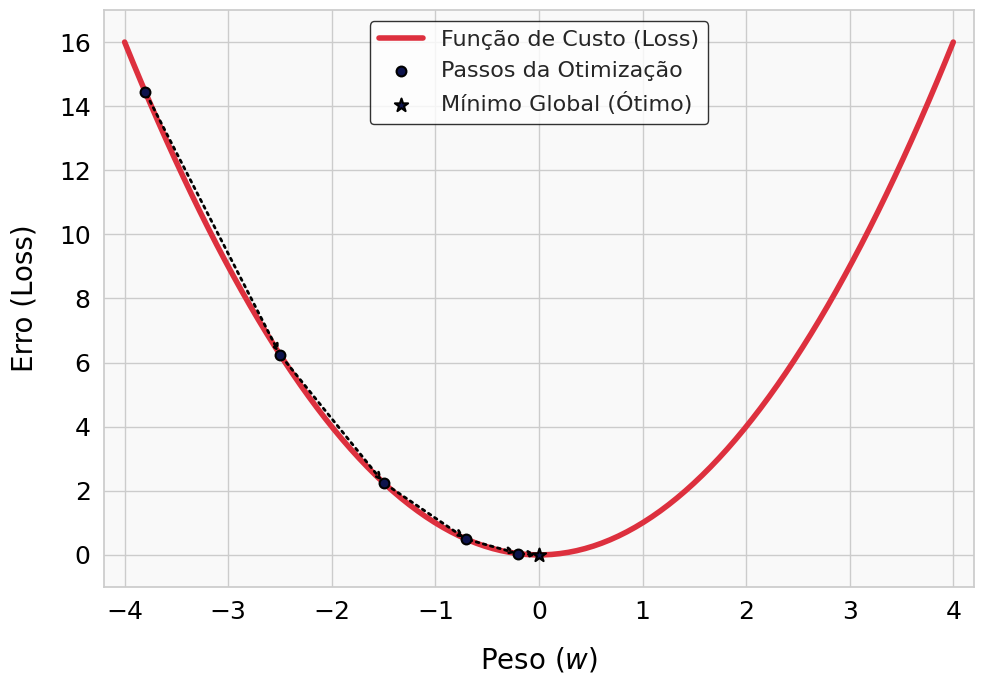

In [21]:
# 1. Geração de Dados Sintéticos (A Curva de Erro / Parábola)
w = np.linspace(-4, 4, 100)
loss = w**2

# 2. Simulação do caminho da Descida do Gradiente
# Começamos em w = -3.8 (alto erro) e descemos em direção a w = 0 (mínimo)
passos_w = [-3.8, -2.5, -1.5, -0.7, -0.2, 0.0]
passos_loss = [pw**2 for pw in passos_w]

# 3. Criação da Figura
fig, ax = plt.subplots(figsize=(10, 7))

# 4. Plotagem da Curva de Erro Principal (Agora no Vermelho Institucional)
ax.plot(w, loss, color=COR_VERMELHO, linewidth=4, label='Função de Custo (Loss)')

# 5. Plotagem das Setas (A Descida do Gradiente com alpha reduzido)
for i in range(len(passos_w) - 1):
    # Coordenadas atuais e do próximo passo
    origem = (passos_w[i], passos_loss[i])
    destino = (passos_w[i+1], passos_loss[i+1])
    
    ax.annotate('', xy=destino, xytext=origem,
                arrowprops=dict(arrowstyle="->",
                                linestyle=":", 
                                color=COR_PRETO, 
                                alpha=1, 
                                lw=2, 
                                mutation_scale=10, 
                                shrinkA=2, shrinkB=2)) 

# 6. Plotagem dos Pontos Intermediários (Agora no Azul Institucional)
ax.scatter(passos_w[:-1], passos_loss[:-1], 
           color=COR_AZUL_PRINCIPAL, s=50, zorder=5, 
           edgecolor=COR_PRETO, linewidth=1.5, label='Passos da Otimização')

# Ponto final em super destaque (O Mínimo Global - Azul Institucional)
ax.scatter([passos_w[-1]], [passos_loss[-1]], 
           color=COR_AZUL_PRINCIPAL, s=100, zorder=6, marker='*', 
           edgecolor=COR_PRETO, linewidth=1.5, label='Mínimo Global (Ótimo)')

# 7. Configuração dos Labels e Eixos
ax.set_xlabel(r'Peso ($w$)', fontsize=FONT_LABEL, color=COR_PRETO, labelpad=15)
ax.set_ylabel(r'Erro (Loss)', fontsize=FONT_LABEL, color=COR_PRETO, labelpad=15)

ax.tick_params(axis='both', labelsize=FONT_TICK, colors=COR_PRETO)

# Ajuste fino de limites para dar um respiro ao redor da curva
ax.set_xlim(-4.2, 4.2)
ax.set_ylim(-1, 17)

# Adicionando uma legenda centralizada (Aproveitando o espaço vazio da parábola)
ax.legend(fontsize=16, loc='upper center', frameon=True, facecolor=COR_BRANCO, edgecolor=COR_PRETO)

# Ajuste do Layout
plt.tight_layout()

# 8. Salvamento da Imagem
caminho_save = os.path.join('..', 'outputs', 'figures', 'aula_06')
os.makedirs(caminho_save, exist_ok=True)

# Exportação em 300 DPI com as bordas tratadas para inserção perfeita no PDF
plt.savefig(os.path.join(caminho_save, '06_figura_curva_erro_2d.png'), 
            dpi=300, 
            bbox_inches='tight', 
            pad_inches=0.4)

# Exibição do Gráfico
plt.show()